# EpidemicWatch — Phase 2: Data Preparation & Non-IID Hospital Partitioning

This notebook prepares the **Symptom2Disease** dataset for the EpidemicWatch federated
outbreak-detection project. It:

1. Loads and cleans the raw dataset
2. Regroups the 24 diseases into broader **syndrome categories** (needed because
   50 examples/disease is too sparse to split across multiple simulated hospitals)
3. Splits the data into **non-IID** hospital shards (Dirichlet distribution) and a
   matching **IID** baseline
4. Saves shards + a manifest, with visualizations to sanity-check the splits

> Run this top-to-bottom in Google Colab. Runtime → Change runtime type → CPU is fine
> for this notebook (no model training happens here).

## 0. Setup

In [1]:
import os
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# ---- Config -----------------------------------------------------------
N_HOSPITALS = 3                 # number of simulated district hospitals (reduced from 4 -- see notes)
DIRICHLET_ALPHA = 1.8           # moderate skew, raised from 0.7 to avoid near-empty cells
SPLIT_SEED = 123                # this specific seed was checked to avoid near-empty (hospital, category) cells
                                 # at this alpha/hospital count -- change with care, re-verify no warnings if you do
MIN_CELL_WARNING_THRESHOLD = 5  # warn if any (hospital, category) has fewer examples
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
OUTPUT_DIR = "epidemicwatch_data"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Config set. Hospitals:", N_HOSPITALS, "| Dirichlet alpha:", DIRICHLET_ALPHA)

Config set. Hospitals: 3 | Dirichlet alpha: 1.8


## 1. Load the Dataset

Two ways to get the CSV into Colab — the cell below tries `kagglehub` first
(needs your Kaggle credentials configured in Colab secrets / `kaggle.json`),
and falls back to a manual upload if that fails or if you're not authenticated.


In [2]:
df = None

# --- Attempt 1: kagglehub download -------------------------------------
try:
    import kagglehub
    path = kagglehub.dataset_download("niyarrbarman/symptom2disease")
    print("Downloaded to:", path)
    csv_candidates = [f for f in os.listdir(path) if f.endswith(".csv")]
    assert csv_candidates, "No CSV found in downloaded dataset folder."
    df = pd.read_csv(os.path.join(path, csv_candidates[0]))
    print("Loaded via kagglehub.")
except Exception as e:
    print("kagglehub download failed or not configured:", e)
    print("Falling back to manual upload below.")

# --- Attempt 2: manual upload (only runs if df is still None) ----------
if df is None:
    from google.colab import files
    print("Please upload the Symptom2Disease CSV file (e.g. Symptom2Disease.csv).")
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    df = pd.read_csv(fname)
    print("Loaded via manual upload:", fname)

print("\nShape:", df.shape)
df.head()

Downloaded to: C:\Users\Mridul Tripathi\.cache\kagglehub\datasets\niyarrbarman\symptom2disease\versions\1
Loaded via kagglehub.

Shape: (1200, 3)


,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


## 2. Clean the Data

In [3]:
# Drop the unnamed index column if present (common in this dataset's CSV export)
unnamed_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
if unnamed_cols:
    df = df.drop(columns=unnamed_cols)
    print("Dropped index column(s):", unnamed_cols)

# Standardize column names just in case of casing differences
df.columns = [c.strip().lower() for c in df.columns]
assert "label" in df.columns and "text" in df.columns, f"Unexpected columns: {df.columns.tolist()}"

# Nulls / duplicates check
print("Nulls per column:\n", df.isnull().sum())
n_dupes = df.duplicated(subset=["text"]).sum()
print(f"\nDuplicate text rows: {n_dupes}")
df = df.drop_duplicates(subset=["text"]).dropna(subset=["label", "text"]).reset_index(drop=True)

def clean_text(t):
    t = str(t).strip()
    t = re.sub(r"\s+", " ", t)                 # collapse whitespace
    t = re.sub(r"[^\w\s.,!?'-]", "", t)         # strip stray punctuation, keep clinical terms intact
    return t

df["text"] = df["text"].apply(clean_text)
df["label"] = df["label"].str.strip()

print(f"\nCleaned shape: {df.shape}")
print(f"Unique diseases ({df['label'].nunique()}):")
print(sorted(df["label"].unique().tolist()))

Dropped index column(s): ['Unnamed: 0']
Nulls per column:
 label    0
text     0
dtype: int64

Duplicate text rows: 47

Cleaned shape: (1153, 2)
Unique diseases (24):
['Acne', 'Arthritis', 'Bronchial Asthma', 'Cervical spondylosis', 'Chicken pox', 'Common Cold', 'Dengue', 'Dimorphic Hemorrhoids', 'Fungal infection', 'Hypertension', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine', 'Pneumonia', 'Psoriasis', 'Typhoid', 'Varicose Veins', 'allergy', 'diabetes', 'drug reaction', 'gastroesophageal reflux disease', 'peptic ulcer disease', 'urinary tract infection']


## 3. Regroup 24 Diseases into Syndrome Categories

50 examples per disease is too sparse to split across multiple hospitals in a
non-IID way without some cells collapsing to near-zero. We collapse into **5
broader syndrome categories** suitable for outbreak-style surveillance.

> **Revision note:** an earlier version of this notebook used 6 categories
> including a standalone "Neurological" bucket, but that category ended up
> containing only Migraine (~47 examples total) once UTI was correctly moved to
> "Musculoskeletal/Other" -- too thin on its own, and it produced several
> near-empty (hospital, category) cells after non-IID splitting. Neurological has
> been merged into "Musculoskeletal/Other" below. We've also reduced to **3
> hospitals** (from 4) and raised the Dirichlet alpha to **1.3** (from 0.7) to
> avoid near-empty cells and reduce extreme total-size imbalance across hospitals.

**Review this mapping carefully** — it's built from general medical knowledge and
printed for your inspection below. Diseases that could reasonably fit more than one
category are flagged in comments; edit the dictionary directly if you disagree with
a placement.

The code below is **data-driven**: it only uses categories for diseases it finds in
your actual loaded CSV, and it will loudly warn you about any disease label present
in the data that isn't in the mapping dictionary yet (dataset label spelling can vary
slightly between CSV exports), so nothing silently falls through the cracks.

In [4]:
# Disease -> syndrome category mapping.
# NOTE: casing below was verified directly against the actual Symptom2Disease CSV
# (confirmed via df["label"].unique() on a real run) -- several labels are
# lowercase in the source data even though most are Title Case. If Kaggle updates
# the dataset and casing changes, the validation check below will catch it.
DISEASE_TO_SYNDROME = {
    # --- Respiratory ---
    "Common Cold":              "Respiratory",
    "Bronchial Asthma":         "Respiratory",
    "Pneumonia":                "Respiratory",

    # --- Gastrointestinal ---
    "gastroesophageal reflux disease": "Gastrointestinal",
    "peptic ulcer disease":     "Gastrointestinal",
    "Dimorphic Hemorrhoids":    "Gastrointestinal",   # ambiguous: could be "Other" -- kept here as GI-tract related
    "Jaundice":                 "Gastrointestinal",   # ambiguous: liver-related, could be "Febrile/Systemic"

    # --- Febrile / Systemic (classic outbreak-relevant infectious diseases) ---
    "Typhoid":                  "Febrile/Systemic",
    "Dengue":                   "Febrile/Systemic",
    "Malaria":                  "Febrile/Systemic",
    "Chicken pox":              "Febrile/Systemic",
    "drug reaction":            "Febrile/Systemic",   # ambiguous: could be "Dermatological" if rash-dominant

    # --- Dermatological ---
    "Psoriasis":                "Dermatological",
    "Acne":                     "Dermatological",
    "Impetigo":                 "Dermatological",
    "Fungal infection":         "Dermatological",
    "allergy":                  "Dermatological",     # ambiguous: could be "Respiratory" if presenting as rhinitis

    # --- Musculoskeletal / Other ---
    # (Merged with the former standalone "Neurological" bucket, which was too thin
    # on its own -- see revision note above. This is now a general "systems not
    # covered elsewhere" bucket: musculoskeletal, neurological, cardiovascular,
    # metabolic, genitourinary.)
    "Arthritis":                "Musculoskeletal/Other",
    "Cervical spondylosis":     "Musculoskeletal/Other",
    "Varicose Veins":           "Musculoskeletal/Other",
    "Hypertension":             "Musculoskeletal/Other",  # ambiguous: cardiovascular, no clean bucket here
    "diabetes":                 "Musculoskeletal/Other",  # ambiguous: metabolic, no clean bucket here
    "Migraine":                 "Musculoskeletal/Other",  # formerly its own "Neurological" category (too thin alone)
    "urinary tract infection":  "Musculoskeletal/Other",  # genitourinary, no clean bucket here
}

# --- Apply mapping, data-driven validation --------------------------------
actual_labels = set(df["label"].unique())
mapped_labels = set(DISEASE_TO_SYNDROME.keys())

missing = actual_labels - mapped_labels
extra = mapped_labels - actual_labels

if missing:
    print("!! WARNING: these labels are in your data but NOT in the mapping dict:")
    for m in sorted(missing):
        print("   -", repr(m))
    print("   -> Add them to DISEASE_TO_SYNDROME above and re-run this cell.")
else:
    print("All disease labels in the dataset are covered by the mapping. Good.")

if extra:
    print("\n(Info) These mapping entries aren't present in your data (harmless, likely spelling variants):")
    for e in sorted(extra):
        print("   -", repr(e))

df["syndrome_category"] = df["label"].map(DISEASE_TO_SYNDROME)
unmapped_rows = df["syndrome_category"].isnull().sum()
if unmapped_rows:
    print(f"\n!! {unmapped_rows} rows have NO syndrome category assigned -- fix the mapping before proceeding.")

print("\nFinal mapping table:")
mapping_df = pd.DataFrame(sorted(DISEASE_TO_SYNDROME.items()), columns=["disease", "syndrome_category"])
mapping_df = mapping_df[mapping_df["disease"].isin(actual_labels)]
print(mapping_df.to_string(index=False))

All disease labels in the dataset are covered by the mapping. Good.

Final mapping table:
                        disease     syndrome_category
                           Acne        Dermatological
                      Arthritis Musculoskeletal/Other
               Bronchial Asthma           Respiratory
           Cervical spondylosis Musculoskeletal/Other
                    Chicken pox      Febrile/Systemic
                    Common Cold           Respiratory
                         Dengue      Febrile/Systemic
          Dimorphic Hemorrhoids      Gastrointestinal
               Fungal infection        Dermatological
                   Hypertension Musculoskeletal/Other
                       Impetigo        Dermatological
                       Jaundice      Gastrointestinal
                        Malaria      Febrile/Systemic
                       Migraine Musculoskeletal/Other
                      Pneumonia           Respiratory
                      Psoriasis        Dermato

### 3a. Sanity-check category sizes

syndrome_category
Musculoskeletal/Other    342
Dermatological           246
Febrile/Systemic         243
Gastrointestinal         177
Respiratory              145
Name: count, dtype: int64


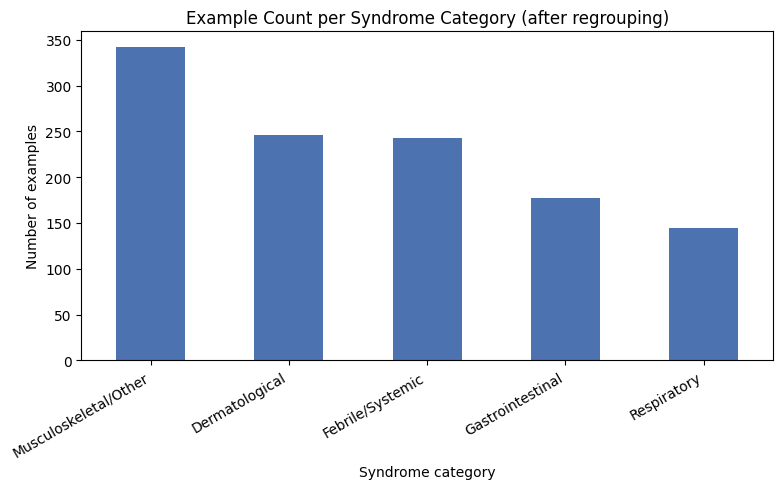

In [5]:
category_counts = df["syndrome_category"].value_counts().sort_values(ascending=False)
print(category_counts)

thin_categories = category_counts[category_counts < 45]
if len(thin_categories):
    print("\n!! These categories are thinner than ~45 examples -- consider merging them:")
    print(thin_categories)

plt.figure(figsize=(8, 5))
category_counts.plot(kind="bar", color="#4C72B0")
plt.title("Example Count per Syndrome Category (after regrouping)")
plt.ylabel("Number of examples")
plt.xlabel("Syndrome category")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "category_counts.png"), dpi=150)
plt.show()

## 4. Non-IID Partitioning Across Simulated Hospitals

We use a **Dirichlet distribution** to assign each hospital a different mixture over
syndrome categories, then sample records from each category to fill that mixture.
A moderate `alpha` (0.5–1.0) gives realistic skew without emptying any cell out
completely. We also build a matching **IID** split (even distribution) for comparison.

In [6]:
def dirichlet_non_iid_split(df, n_hospitals, alpha, category_col="syndrome_category", seed=42):
    """
    Partition df into n_hospitals non-IID shards using a Dirichlet distribution
    per category. Returns a dict: {hospital_id: DataFrame}.
    """
    rng = np.random.default_rng(seed)
    categories = sorted(df[category_col].unique())
    hospital_indices = {h: [] for h in range(n_hospitals)}

    for cat in categories:
        cat_idx = df.index[df[category_col] == cat].to_numpy().copy()
        rng.shuffle(cat_idx)

        # Dirichlet proportions for this category across hospitals
        proportions = rng.dirichlet(alpha=[alpha] * n_hospitals)
        # Convert proportions to integer split points
        split_counts = (proportions * len(cat_idx)).astype(int)
        # Fix rounding so all examples get assigned
        remainder = len(cat_idx) - split_counts.sum()
        for i in range(remainder):
            split_counts[i % n_hospitals] += 1

        start = 0
        for h in range(n_hospitals):
            n = split_counts[h]
            hospital_indices[h].extend(cat_idx[start:start + n].tolist())
            start += n

    shards = {h: df.loc[idxs].reset_index(drop=True) for h, idxs in hospital_indices.items()}
    return shards


def iid_split(df, n_hospitals, category_col="syndrome_category", seed=42):
    """Even, stratified split across hospitals -- the IID baseline."""
    rng = np.random.default_rng(seed)
    categories = sorted(df[category_col].unique())
    hospital_indices = {h: [] for h in range(n_hospitals)}

    for cat in categories:
        cat_idx = df.index[df[category_col] == cat].to_numpy().copy()
        rng.shuffle(cat_idx)
        chunks = np.array_split(cat_idx, n_hospitals)
        for h, chunk in enumerate(chunks):
            hospital_indices[h].extend(chunk.tolist())

    shards = {h: df.loc[idxs].reset_index(drop=True) for h, idxs in hospital_indices.items()}
    return shards


def print_shard_warnings(shards, category_col="syndrome_category", threshold=MIN_CELL_WARNING_THRESHOLD):
    print(f"Checking for (hospital, category) cells below {threshold} examples...")
    any_warning = False
    for h, shard in shards.items():
        counts = shard[category_col].value_counts()
        for cat in df[category_col].unique():
            n = counts.get(cat, 0)
            if n < threshold:
                print(f"  !! Hospital {h} | {cat}: only {n} examples")
                any_warning = True
    if not any_warning:
        print("  No degenerate cells found. Split looks usable.")


non_iid_shards = dirichlet_non_iid_split(df, N_HOSPITALS, DIRICHLET_ALPHA, seed=SPLIT_SEED)
print("=== Non-IID split ===")
print_shard_warnings(non_iid_shards)

iid_shards = iid_split(df, N_HOSPITALS, seed=SPLIT_SEED)
print("\n=== IID split (sanity check, should have no warnings) ===")
print_shard_warnings(iid_shards)

=== Non-IID split ===
Checking for (hospital, category) cells below 5 examples...
  No degenerate cells found. Split looks usable.

=== IID split (sanity check, should have no warnings) ===
Checking for (hospital, category) cells below 5 examples...
  No degenerate cells found. Split looks usable.


## 5. Visualize the Splits

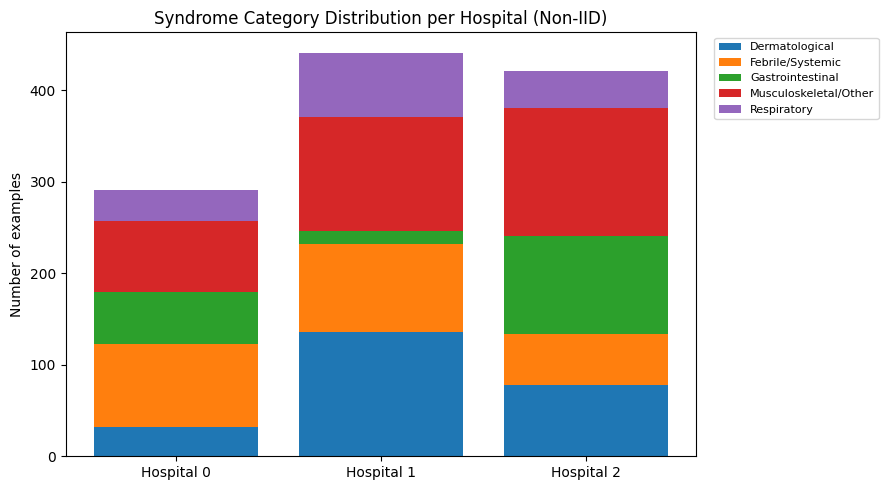

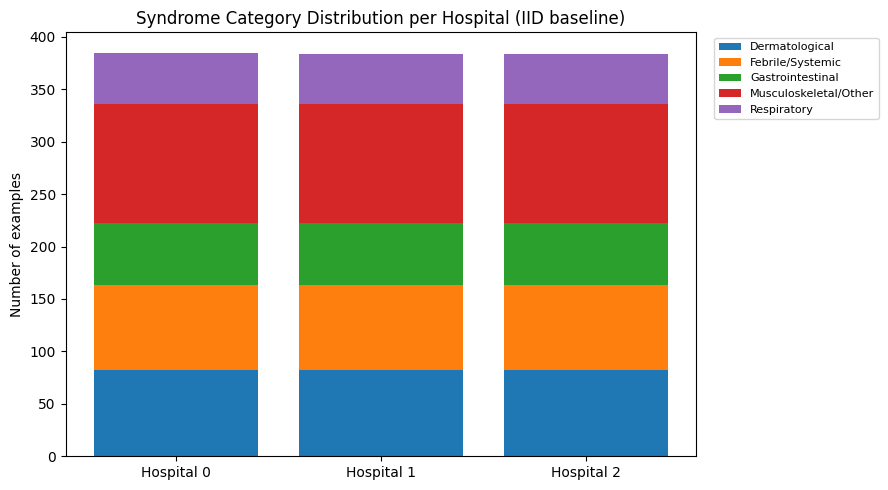

In [7]:
def plot_shard_distribution(shards, title, filename):
    categories = sorted(df["syndrome_category"].unique())
    hospitals = sorted(shards.keys())
    counts_matrix = np.array([
        [ (shards[h]["syndrome_category"] == cat).sum() for cat in categories ]
        for h in hospitals
    ])

    fig, ax = plt.subplots(figsize=(9, 5))
    bottom = np.zeros(len(hospitals))
    colors = plt.cm.tab10.colors
    for i, cat in enumerate(categories):
        ax.bar([f"Hospital {h}" for h in hospitals], counts_matrix[:, i],
               bottom=bottom, label=cat, color=colors[i % len(colors)])
        bottom += counts_matrix[:, i]

    ax.set_title(title)
    ax.set_ylabel("Number of examples")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=150)
    plt.show()

plot_shard_distribution(non_iid_shards, "Syndrome Category Distribution per Hospital (Non-IID)", "non_iid_distribution.png")
plot_shard_distribution(iid_shards, "Syndrome Category Distribution per Hospital (IID baseline)", "iid_distribution.png")

## 6. Train / Val / Test Split Within Each Hospital Shard

Stratified by syndrome category where the shard is large enough; falls back to a
plain random split for any category too small to stratify safely.

In [8]:
from sklearn.model_selection import train_test_split

def stratified_shard_split(shard_df, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC, test_frac=TEST_FRAC,
                            category_col="syndrome_category", seed=42):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6

    # Only stratify if every category has enough rows for a safe split
    counts = shard_df[category_col].value_counts()
    can_stratify = (counts >= 3).all()
    strat_col = shard_df[category_col] if can_stratify else None

    train_df, temp_df = train_test_split(
        shard_df, train_size=train_frac, random_state=seed, stratify=strat_col
    )
    relative_val = val_frac / (val_frac + test_frac)
    strat_col_temp = temp_df[category_col] if can_stratify else None
    val_df, test_df = train_test_split(
        temp_df, train_size=relative_val, random_state=seed, stratify=strat_col_temp
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def build_splits_for_all_hospitals(shards):
    result = {}
    for h, shard in shards.items():
        train_df, val_df, test_df = stratified_shard_split(shard)
        result[h] = {"train": train_df, "val": val_df, "test": test_df}
    return result

non_iid_splits = build_splits_for_all_hospitals(non_iid_shards)
iid_splits = build_splits_for_all_hospitals(iid_shards)

print("Non-IID split sizes (train/val/test) per hospital:")
for h, d in non_iid_splits.items():
    print(f"  Hospital {h}: {len(d['train'])} / {len(d['val'])} / {len(d['test'])}")

Non-IID split sizes (train/val/test) per hospital:
  Hospital 0: 203 / 44 / 44
  Hospital 1: 308 / 66 / 67
  Hospital 2: 294 / 63 / 64


## 7. Save Shards + Manifest to Disk

In [9]:
def save_splits(splits, split_type_name):
    """split_type_name is 'non_iid' or 'iid'"""
    manifest = {"split_type": split_type_name, "n_hospitals": len(splits),
                "dirichlet_alpha": DIRICHLET_ALPHA if split_type_name == "non_iid" else None,
                "hospitals": {}}

    for h, d in splits.items():
        hospital_dir = os.path.join(OUTPUT_DIR, split_type_name, f"hospital_{h}")
        os.makedirs(hospital_dir, exist_ok=True)
        for part in ["train", "val", "test"]:
            d[part].to_csv(os.path.join(hospital_dir, f"{part}.csv"), index=False)

        full_shard = pd.concat([d["train"], d["val"], d["test"]])
        manifest["hospitals"][f"hospital_{h}"] = {
            "total_size": len(full_shard),
            "train_size": len(d["train"]),
            "val_size": len(d["val"]),
            "test_size": len(d["test"]),
            "category_distribution": full_shard["syndrome_category"].value_counts().to_dict(),
        }

    manifest_path = os.path.join(OUTPUT_DIR, f"manifest_{split_type_name}.json")
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2)
    print(f"Saved {split_type_name} shards + manifest to: {os.path.join(OUTPUT_DIR, split_type_name)}")
    return manifest_path

non_iid_manifest_path = save_splits(non_iid_splits, "non_iid")
iid_manifest_path = save_splits(iid_splits, "iid")

Saved non_iid shards + manifest to: epidemicwatch_data\non_iid
Saved iid shards + manifest to: epidemicwatch_data\iid


## 8. Summary Statistics

In [10]:
def word_count(text):
    return len(str(text).split())

print("=" * 60)
print("OVERALL DATASET")
print("=" * 60)
print(f"Total records after cleaning: {len(df)}")
print(f"Number of syndrome categories: {df['syndrome_category'].nunique()}")
print(f"Vocabulary size (unique words, lowercased): "
      f"{len(set(' '.join(df['text'].str.lower()).split()))}")
print(f"Average text length (words): {df['text'].apply(word_count).mean():.1f}")

print("\n" + "=" * 60)
print("PER-HOSPITAL SUMMARY (Non-IID split)")
print("=" * 60)
for h, shard in non_iid_shards.items():
    print(f"\nHospital {h}: {len(shard)} records")
    print(shard['syndrome_category'].value_counts().to_string())

print("\n" + "=" * 60)
print("PER-HOSPITAL SUMMARY (IID split)")
print("=" * 60)
for h, shard in iid_shards.items():
    print(f"\nHospital {h}: {len(shard)} records")
    print(shard['syndrome_category'].value_counts().to_string())

OVERALL DATASET
Total records after cleaning: 1153
Number of syndrome categories: 5
Vocabulary size (unique words, lowercased): 2397
Average text length (words): 30.6

PER-HOSPITAL SUMMARY (Non-IID split)

Hospital 0: 291 records
syndrome_category
Febrile/Systemic         91
Musculoskeletal/Other    78
Gastrointestinal         56
Respiratory              34
Dermatological           32

Hospital 1: 441 records
syndrome_category
Dermatological           136
Musculoskeletal/Other    125
Febrile/Systemic          96
Respiratory               70
Gastrointestinal          14

Hospital 2: 421 records
syndrome_category
Musculoskeletal/Other    139
Gastrointestinal         107
Dermatological            78
Febrile/Systemic          56
Respiratory               41

PER-HOSPITAL SUMMARY (IID split)

Hospital 0: 385 records
syndrome_category
Musculoskeletal/Other    114
Dermatological            82
Febrile/Systemic          81
Gastrointestinal          59
Respiratory               49

Hospital 1: 3

## 9. (Optional) Zip everything for download / Google Drive

Run this cell if you want a single archive to move into Phase 3.

In [11]:
import shutil
zip_path = shutil.make_archive("epidemicwatch_data", "zip", OUTPUT_DIR)
print("Created archive:", zip_path)

# Uncomment to download directly in Colab:
# from google.colab import files
# files.download(zip_path)

Created archive: C:\Users\Mridul Tripathi\OneDrive\Desktop\EpidemicWatch\epidemicwatch_data.zip
